In [1]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

In [2]:
path = "test_image/Lenna_(test_image).png"

img = Image.open(path).convert("RGB")


In [3]:
class JPEGCodec:
    def __init__(self, block_size: int = 8, q_y: int = 10, q_c: int = 16):
        self.N = block_size
        self.C = self._dct_matrix(block_size)
        self.q_y = q_y
        self.q_c = q_c

    def _dct_matrix(self, N: int) -> np.ndarray:
        C = np.zeros((N, N), dtype=np.float64)
        for i in range(N):
            for j in range(N):
                alpha = np.sqrt(1 / N) if i == 0 else np.sqrt(2 / N)
                C[i, j] = alpha * np.cos(((2 * j + 1) * i * np.pi) / (2 * N))
        return C
    
    def _split_blocks(self, channel):
        H, W = channel.shape
        assert H % self.N == 0 and W % self.N == 0, "Image dimensions must be divisible by block size"
        return channel.reshape(
            H // self.N, self.N,
            W // self.N, self.N
        ).transpose(0, 2, 1, 3)

    def _merge_blocks(self, blocks):
        nb_h, nb_w, bh, bw = blocks.shape
        return blocks.transpose(0, 2, 1, 3).reshape(nb_h * bh, nb_w * bw)
    
    def _dct2(self, block):
        return self.C @ block @ self.C.T
    
    def _idct2(self, block):
        return self.C.T @ block @ self.C
    
    def transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._dct2(blocks[i, j])
        return out
    
    def inverse_transform_blocks(self, blocks):
        out = np.empty_like(blocks, dtype=np.float64)
        for i in range(blocks.shape[0]):
            for j in range(blocks.shape[1]):
                out[i, j] = self._idct2(blocks[i, j])
        return out
    
    
    def transform(self, image: Image.Image) -> dict:
        image = image.convert("YCbCr")
        arr = np.asarray(image, dtype=np.uint8).astype(np.float64) - 128.0
        channels = []

        for c in range(3):
            blocks = self._split_blocks(arr[:, :, c])
            dct_blocks = self.transform_blocks(blocks)
            channels.append(dct_blocks)

        return {
            "ch1": channels[0],
            "ch2": channels[1],
            "ch3": channels[2]
        }

    def inverse_transform(self, encoded: dict) -> Image.Image:
        rec_channels = []

        for key in ["ch1", "ch2", "ch3"]:
            blocks = self.inverse_transform_blocks(encoded[key])
            rec_channels.append(self._merge_blocks(blocks))
        
        rec = np.stack(rec_channels, axis=-1)
        return Image.fromarray(np.clip(rec + 128.0, 0, 255).astype(np.uint8), mode="YCbCr").convert("RGB")
    

    # Quantization
    def quantize(self, transformed: dict) -> dict:
        quantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            quantized[key] = np.round(transformed[key] / q).astype(np.int32)
        return quantized
    
    def dequantize(self, quantized: dict) -> dict:
        dequantized = {}
        for key in ["ch1", "ch2", "ch3"]:
            q = self.q_y if key == "ch1" else self.q_c
            dequantized[key] = (quantized[key] * q).astype(np.float64)
        return dequantized
    
    # Zigzag scan
    def _zigzag_indices(self, N: int) -> np.ndarray:
        indices = []

        for s in range(2 * N - 1):
            if s % 2 == 0:
                for i in range(s, -1, -1):
                    j = s - i
                    if i < N and j < N:
                        indices.append((i, j))
            else:
                for j in range(s, -1, -1):
                    i = s - j
                    if i < N and j < N:
                        indices.append((i, j))
        return np.array(indices)
    
    def zigzag_scan(self, block):
        return np.array([block[i, j] for i, j in self._zigzag_indices(self.N)], dtype=np.int32)
    
    def zigzag_unscan(self, arr):
        block = np.zeros((self.N, self.N), dtype=np.int32)

        for idx, (i, j) in enumerate(self._zigzag_indices(self.N)):
            block[i, j] = arr[idx]
        return block
    
    # DC - DPCM
    def DPCM_encode(self, dc_values) -> np.ndarray:
        dc_values = np.asarray(dc_values, dtype=np.int32)

        diffs = np.empty_like(dc_values)
        previous = 0

        for i, dc in enumerate(dc_values):
            diffs[i] = dc - previous
            previous = dc

        return diffs
    
    def DPCM_decode(self, dc_diffs) -> np.ndarray:
        dc_diffs = np.asarray(dc_diffs, dtype=np.int32)

        dc_values = np.empty_like(dc_diffs)
        previous = 0

        for i, diff in enumerate(dc_diffs):
            dc_values[i] = diff + previous
            previous = dc_values[i]

        return dc_values
    
    # AC Run-length coding
    def RL_encode(self, arr):
        arr = np.asarray(arr, dtype=np.int32)
        symbols = []
        zero_run = 0

        for value in arr:
            value = int(value)

            if value == 0:
                zero_run += 1
            else:
                symbols.append((zero_run, value))
                zero_run = 0

        symbols.append(("EOB",))
        return symbols
    
    def RL_decode(self, symbols):
        ac = []
        for symbol in symbols:
            if symbol[0] == "EOB":
                break

            zero_run, value = symbol
            ac.extend([0] * zero_run)
            ac.append(value)

        target_length = self.N * self.N - 1
        ac.extend([0] * (target_length - len(ac)))
        return np.array(ac[:target_length], dtype=np.int32)

    # Entropy coding
    def entropy_encode(self, q_blocks):
        dc_values = []
        ac_symbols = []

        for i in range(q_blocks.shape[0]):
            for j in range(q_blocks.shape[1]):
                zz = self.zigzag_scan(q_blocks[i, j])

                dc_values.append(int(zz[0]))
                ac_symbols.append(self.RL_encode(zz[1:]))
        dc_diffs = self.DPCM_encode(dc_values)
        return {"dc_diffs": dc_diffs, "ac_symbols": ac_symbols, "shape": q_blocks.shape}

    def entropy_decode(self, encoded):
        nb_h, nb_w, _, _ = encoded["shape"]
        dc_values = self.DPCM_decode(encoded["dc_diffs"])
        ac_symbols = encoded["ac_symbols"]

        blocks = np.empty((nb_h, nb_w, self.N, self.N), dtype=np.int32)

        k = 0
        for i in range(nb_h):
            for j in range(nb_w):
                dc = dc_values[k]
                ac = self.RL_decode(ac_symbols[k])

                zz = np.concatenate(([dc], ac))
                blocks[i, j] = self.zigzag_unscan(zz)
                k += 1

        return blocks

    def encode(self, image: Image.Image) -> dict:
        transformed = self.transform(image)
        quantized = self.quantize(transformed)
        entropy_encoded = {key: self.entropy_encode(quantized[key]) for key in ["ch1", "ch2", "ch3"]}
        return entropy_encoded
    
    def decode(self, encoded: dict) -> Image.Image:
        entropy_decoded = {key: self.entropy_decode(encoded[key]) for key in ["ch1", "ch2", "ch3"]}
        dequantized = self.dequantize(entropy_decoded)
        output = self.inverse_transform(dequantized)
        return output

In [4]:
codec = JPEGCodec(block_size=8, q_y=40, q_c=40*1.6)
encoded = codec.encode(img)
decoded = codec.decode(encoded)
print(encoded)

{'ch1': {'dc_diffs': array([ 6,  0, -1, ..., -8,  1,  6], shape=(4096,), dtype=int32), 'ac_symbols': [[('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [(0, -1), ('EOB',)], [(0, -1), ('EOB',)], [(0, 1), ('EOB',)], [(0, 3), ('EOB',)], [(4, 1), ('EOB',)], [(0, -1), ('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [(0, -1), ('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [(0, 1), ('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [(0, 1), ('EOB',)], [(0, -2), ('EOB',)], [(0, -1), ('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [(0, -4), (0, 1), ('EOB',)], [(0, -1), ('EOB',)], [(0, 5), (0, -1), (0, 1), (0, 1), (0, -2), (0, 1), (1, -1), ('EOB',)], [(4, 1), ('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('EOB',)], [('

In [5]:
def flatten_symbols(encoded):
    all_dc = []
    all_ac = []

    for key in ["ch1", "ch2", "ch3"]:
        all_dc.extend(encoded[key]["dc_diffs"].tolist())

        for block_symbols in encoded[key]["ac_symbols"]:
            all_ac.extend(block_symbols)

    return all_dc, all_ac
all_dc, all_ac = flatten_symbols(encoded)

print("Number of DC symbols:", len(all_dc))
print("Number of AC symbols:", len(all_ac))
print("First 20 DC symbols:", all_dc[:20])
print("First 20 AC symbols:", all_ac[:20])

Number of DC symbols: 12288
Number of AC symbols: 26376
First 20 DC symbols: [6, 0, -1, 0, 1, 2, 0, -7, -8, 2, 1, 0, 0, 1, 2, 1, 0, 1, -1, 1]
First 20 AC symbols: [('EOB',), ('EOB',), ('EOB',), ('EOB',), (0, -1), ('EOB',), (0, -1), ('EOB',), (0, 1), ('EOB',), (0, 3), ('EOB',), (4, 1), ('EOB',), (0, -1), ('EOB',), ('EOB',), ('EOB',), ('EOB',), (0, -1)]


In [6]:
from collections import Counter
import heapq

class HuffmanNode:
    def __init__(self, left=None, right=None):
        self.left = left
        self.right = right


def build_huffman_codebook(symbols):
    counts = Counter(symbols)

    if len(counts) == 1:
        only_symbol = next(iter(counts))
        return {only_symbol: "0"}

    heap = []
    counter = 0

    for symbol, freq in counts.items():
        heapq.heappush(heap, (freq, counter, symbol))
        counter += 1

    while len(heap) > 1:
        freq1, _, left = heapq.heappop(heap)
        freq2, _, right = heapq.heappop(heap)

        node = HuffmanNode(left, right)
        heapq.heappush(heap, (freq1 + freq2, counter, node))
        counter += 1

    root = heap[0][2]
    codebook = {}

    def assign_codes(node, prefix):
        if isinstance(node, HuffmanNode):
            assign_codes(node.left, prefix + "0")
            assign_codes(node.right, prefix + "1")
        else:
            codebook[node] = prefix

    assign_codes(root, "")
    return codebook
dc_codebook = build_huffman_codebook(all_dc)
ac_codebook = build_huffman_codebook(all_ac)
print("DC codebook size:", len(dc_codebook))
print("AC codebook size:", len(ac_codebook))

#print codebook
print("DC codebook:", dc_codebook)
print("AC codebook:", ac_codebook)

DC codebook size: 58
AC codebook size: 139
DC codebook: {0: '0', 3: '10000', 4: '100010', 6: '1000110', -7: '1000111', 2: '1001', 10: '10100000', 12: '101000010', 17: '1010000110', -19: '10100001110', 22: '101000011110', 23: '101000011111', -4: '1010001', -3: '101001', -15: '101010000', 11: '101010001', 13: '101010010', 14: '101010011', 5: '1010101', 9: '10101100', -10: '10101101', -13: '101011100', 15: '1010111010', 16: '1010111011', -9: '10101111', -2: '10110', -17: '1011100000', -18: '1011100001', -12: '101110001', -8: '10111001', 7: '10111010', -30: '101110110000', 25: '1011101100010', 21: '1011101100011', 18: '10111011001', -16: '1011101101', -20: '10111011100', -27: '101110111010', -25: '101110111011', 19: '101110111100', -23: '101110111101', 24: '1011101111100', -22: '1011101111101', -21: '1011101111110', -29: '1011101111111', -5: '10111100', 8: '10111101', -14: '1011111000', -26: '1011111001000', -31: '1011111001001', -32: '1011111001010', -24: '10111110010110', -33: '101111100

In [7]:
def huffman_length(symbols, codebook):
    return sum(len(codebook[s]) for s in symbols)

In [8]:
L_dc = huffman_length(all_dc, dc_codebook)
L_ac = huffman_length(all_ac, ac_codebook)

L_total = L_dc + L_ac

W, H = img.size
bpp = L_total / (W * H)

print("DC bits:", L_dc)
print("AC bits:", L_ac)
print("Total bits:", L_total)
print("Huffman bpp:", bpp)
print("Compression ratio vs 24 bpp:", 24 / bpp)

DC bits: 34539
AC bits: 87835
Total bits: 122374
Huffman bpp: 0.46681976318359375
Compression ratio vs 24 bpp: 51.4117051007567


In [9]:
from collections import Counter

ac_counts = Counter(all_ac)
dc_counts = Counter(all_dc)

print("Most common AC symbols:")
print(ac_counts.most_common(10))

print("Most common DC symbols:")
print(dc_counts.most_common(10))

Most common AC symbols:
[(('EOB',), 12288), ((0, -1), 3133), ((0, 1), 2805), ((1, 1), 822), ((1, -1), 743), ((0, -2), 724), ((0, 2), 627), ((2, 1), 388), ((3, -1), 379), ((2, -1), 356)]
Most common DC symbols:
[(0, 5874), (1, 1758), (-1, 1739), (2, 690), (-2, 422), (3, 287), (-3, 162), (4, 152), (5, 90), (-4, 80)]


In [10]:
def MSE(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    mse = np.mean((arr_orig - arr_rec) ** 2)
    return mse

def PSNR(original: Image.Image, reconstructed: Image.Image) -> float:
    mse = MSE(original, reconstructed)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10(max_pixel**2 / mse)
    return psnr

def SSIM(original: Image.Image, reconstructed: Image.Image) -> float:
    arr_orig = np.asarray(original, dtype=np.float64)
    arr_rec = np.asarray(reconstructed, dtype=np.float64)
    ssim_value = ssim(arr_orig, arr_rec, multichannel=True, channel_axis=2,data_range=255)
    return ssim_value

def entropy(image: Image.Image) -> float:
    symbols = np.asarray(image, dtype=np.uint8)
    symbols = symbols.ravel()
    values, counts = np.unique(symbols, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))



In [17]:
q_y_values = [1,2,3,4,5,10,20,30,40,50,100, 200]

mse_values = []
psnr_values = []
ssim_values = []
decoded_images = []
estimated_bpps = []

for q_y in q_y_values:
    codec = JPEGCodec(block_size=8, q_y=q_y, q_c=q_y*1.6)
    encoded = codec.encode(img)
    decoded = codec.decode(encoded)

    decoded_images.append(decoded)
    mse_values.append(MSE(img, decoded))
    psnr_values.append(PSNR(img, decoded))
    ssim_values.append(SSIM(img, decoded))


Text(0.5, 1.0, 'SSIM vs Quantization Parameter')

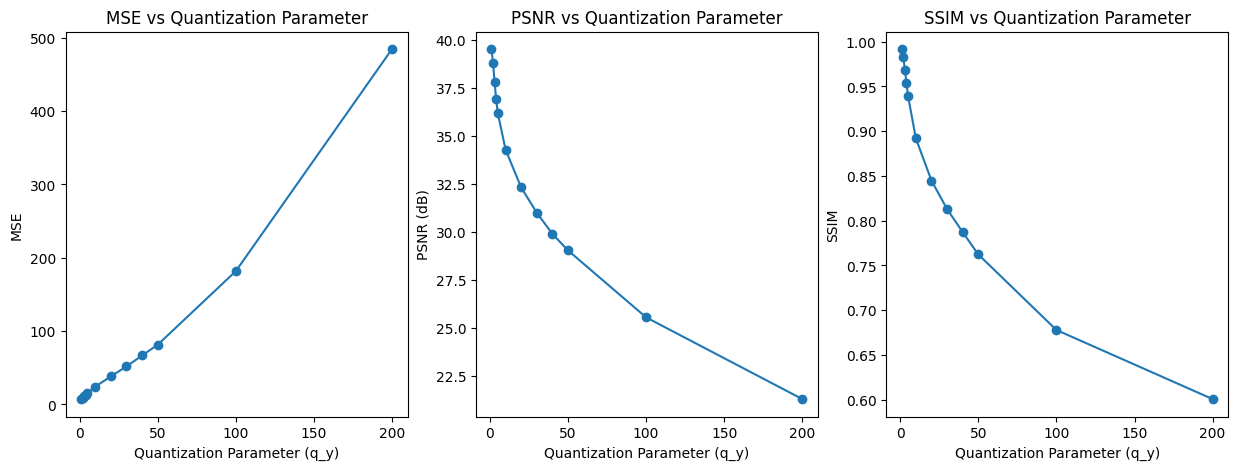

In [18]:
# Plotting the results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(q_y_values, mse_values, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('MSE')
plt.title('MSE vs Quantization Parameter')
plt.subplot(1, 3, 2)
plt.plot(q_y_values, psnr_values, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Quantization Parameter')
plt.subplot(1, 3, 3)
plt.plot(q_y_values, ssim_values, marker='o')
# plt.xscale('log')
plt.xlabel('Quantization Parameter (q_y)')
plt.ylabel('SSIM')
plt.title('SSIM vs Quantization Parameter')
# plt.subplot(1, 3, 4)
# plt.plot(q_y_values, estimated_bpps, marker='o')
# plt.xscale('log')
# plt.xlabel('Quantization Parameter (q_y)')
# plt.ylabel('Estimated BPP')
# plt.title('Estimated BPP vs Quantization Parameter')
# plt.tight_layout()
# plt.show()

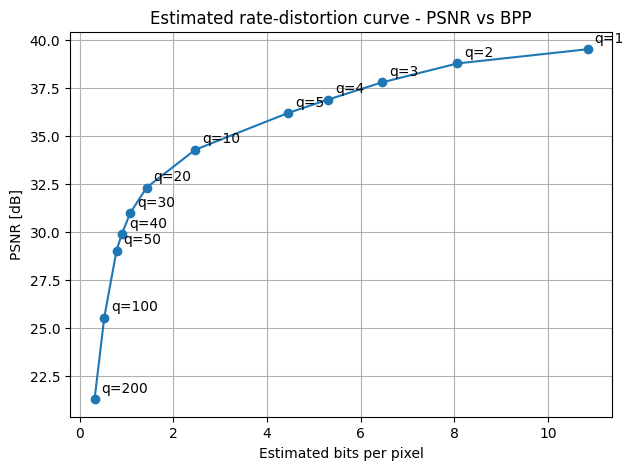

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(estimated_bpps, psnr_values, marker="o")

for bpp, psnr, q in zip(estimated_bpps, psnr_values, q_y_values):
    plt.annotate(f"q={q}", (bpp, psnr), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Estimated bits per pixel")
plt.ylabel("PSNR [dB]")
plt.title("Estimated rate-distortion curve - PSNR vs BPP") 
plt.grid(True)
plt.show()

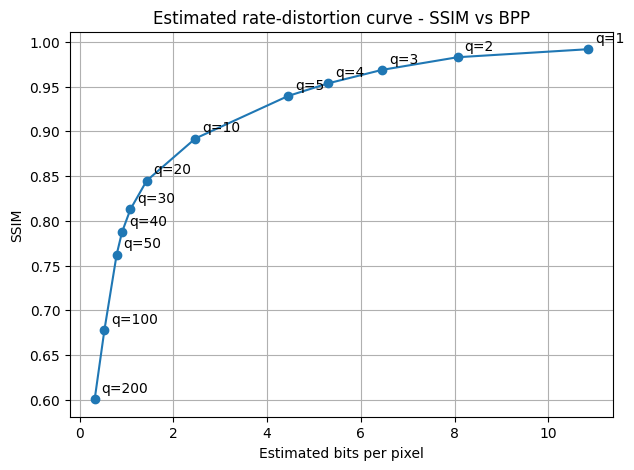

In [105]:
plt.figure(figsize=(7, 5))
plt.plot(estimated_bpps, ssim_values, marker="o")

for bpp, ssim, q in zip(estimated_bpps, ssim_values, q_y_values):
    plt.annotate(f"q={q}", (bpp, ssim), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Estimated bits per pixel")
plt.ylabel("SSIM")
plt.title("Estimated rate-distortion curve - SSIM vs BPP")
plt.grid(True)
plt.show()

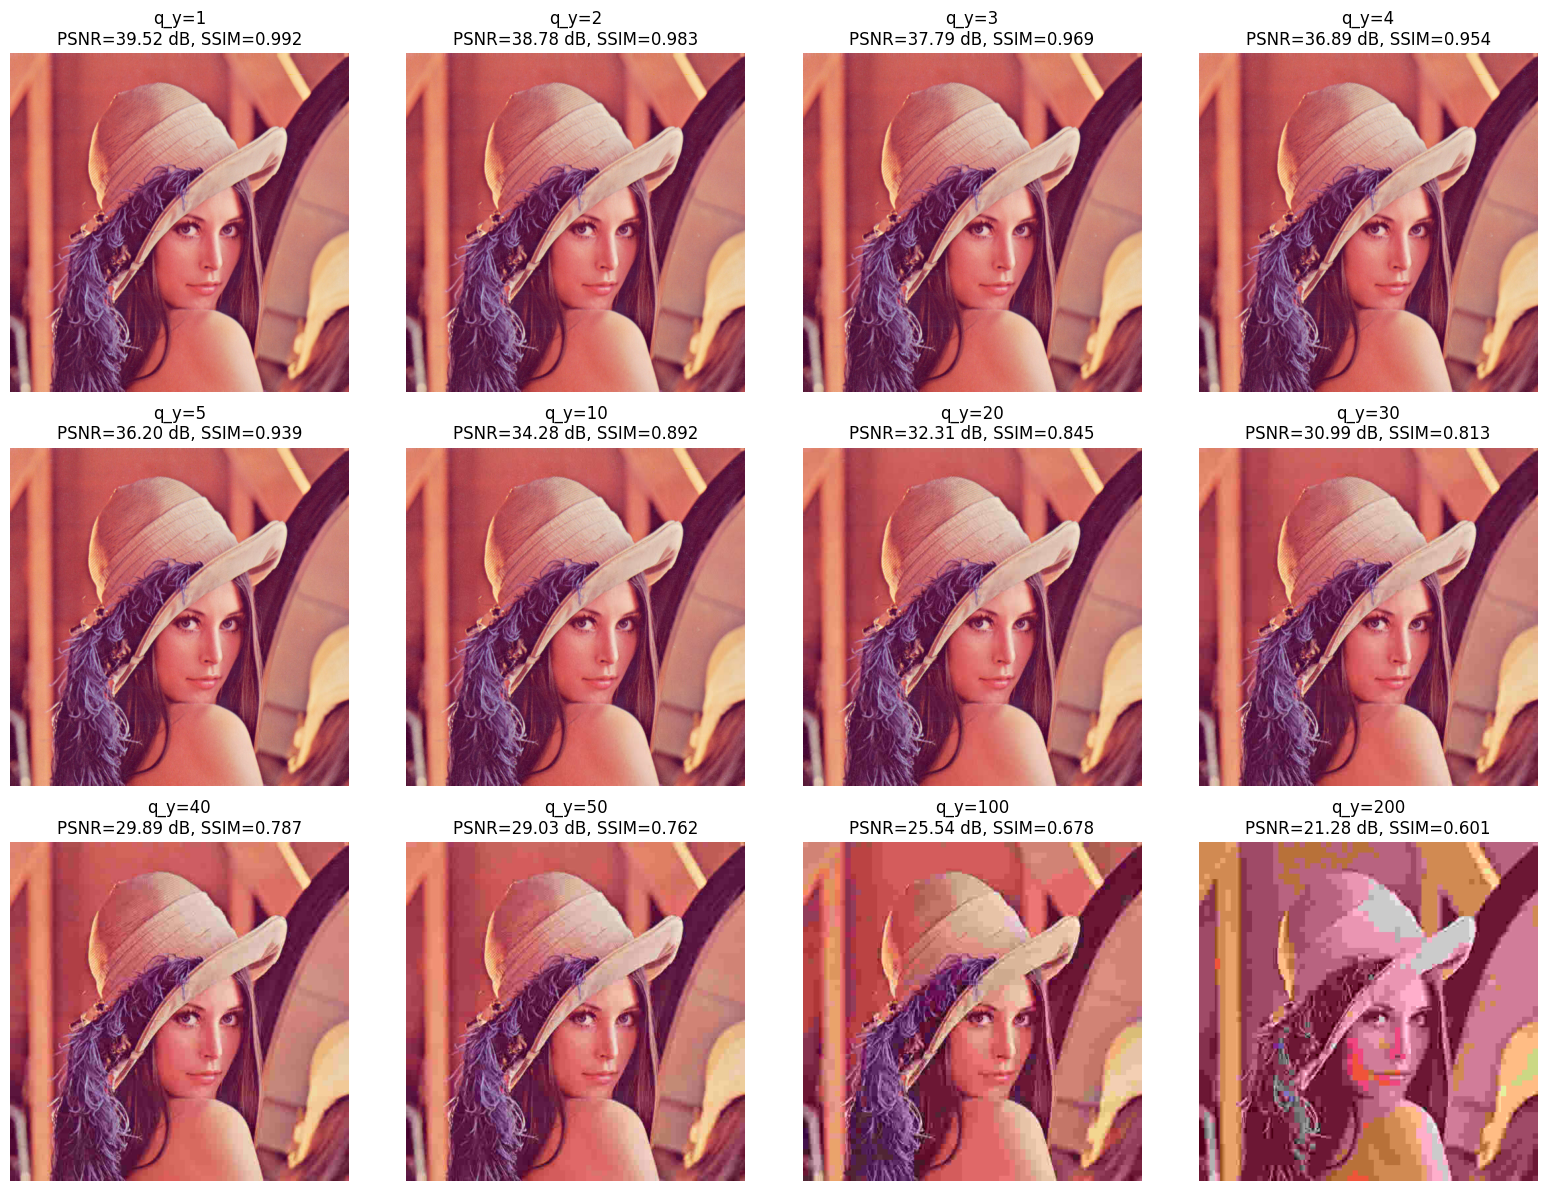

In [19]:
n = len(q_y_values)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, (q_y, decoded, psnr, ssim) in enumerate(
    zip(q_y_values, decoded_images, psnr_values, ssim_values)
):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(decoded)
    plt.title(f"q_y={q_y}\nPSNR={psnr:.2f} dB, SSIM={ssim:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()